# Notebook 1 — Multi-seed training of IsoColBERT (λ=0.5) and vanilla baseline

## Project
IsoColBERT: Token-Level Isotropy Regularization for Multilingual Late-Interaction Retrieval
Minh Tran, Isaac Chang, Ingrid Chien — Harvard University

## What this notebook does
Trains 6 models (3 seeds × {vanilla, IsoColBERT λ=0.5}) for 2000 steps on the OPUS-100 EN-ES parallel split, then evaluates each on FLORES+ for EN-ES, EN-FR, EN-DE, EN-SW, and EN-AR. Geometry diagnostics (intra-cosine, effective rank) are measured on English and Spanish tokens.

**Status:** Trained and evaluated. Results are embedded in cell outputs. Model checkpoints saved to Google Drive at `/MyDrive/iso_colbert_lam0p5/`.

## Outputs produced (or designed to produce)
- 3-seed mean ± std table for 5 languages (MaxSim P@1)
- Per-seed breakdown for audit (EN-SW, EN-AR, EN-DE, intra-cos ES, eRank ES)
- λ=0 vs λ=0.1 vs λ=0.5 comparison table

## Where this feeds into the paper
- Section 5.1 (Retrieval Accuracy) — main retrieval table
- Section 5.2 (Token Geometry) — main geometry table
- Section 6.1 (Lambda Sweep)

## Reproducibility
- **Model**: XLM-RoBERTa-base + 128-dim linear projection (ColBERT-style late interaction)
- **Training data**: OPUS-100 English-Spanish parallel split, streamed from HuggingFace
- **Evaluation**: FLORES+ dev + devtest combined (≈2009 candidates per language)
- **Seeds**: {42, 1337, 2024}
- **Hardware**: Single NVIDIA A100 (Colab Pro). ~1 GPU-hour per training run.
- **Drive layout**: checkpoints save to `/MyDrive/iso_colbert_lam0p5/`, `/MyDrive/iso_colbert_active_token/`, `/MyDrive/iso_colbert_crossattn/`.

---


# IsoColBERT λ=0.5 — Multi-Seed Validation

**Why this notebook.** Single-seed λ ablation (your teammate's run) showed λ=0.5 gives the best low-resource numbers:
- λ=0.0 (vanilla): SW=0.8636, AR=0.9562
- λ=0.1 (your existing baseline): SW=0.8746, AR=0.9562
- **λ=0.5: SW=0.8945, AR=0.9741** (best)

If λ=0.5 holds across 3 seeds, your headline EN-SW gain probably moves from +3.25 P@1 (your existing λ=0.1 multi-seed result) to +5–6 P@1.

**Setup.** Same as your existing notebook — XLM-R + linear projection to 128-dim token vectors, OPUS-100 EN-ES, 2000 steps, batch 8 × grad_accum 4 (effective 32). The ONLY thing that changes is `LAMBDA_ISO = 0.5`.

**Compute.** ~3 hours = 3 seeds × 1 hour each.

**Robustness.** Weights are saved to Google Drive after each seed. If the Colab runtime disconnects, re-running the training cell skips already-completed seeds and resumes.

## Setup

In [1]:
!pip install -q transformers datasets torch

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import XLMRobertaModel, XLMRobertaTokenizerFast, get_linear_schedule_with_warmup
from datasets import load_dataset
import random, gc, os, json
import numpy as np
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters — match existing notebook EXCEPT lambda
LR           = 2e-5
TEMPERATURE  = 0.07
WARMUP_STEPS = 200
BATCH_SIZE   = 8
GRAD_ACCUM   = 4
MAX_STEPS    = 2000
DIM          = 128
LAMBDA_ISO   = 0.5            # <<< KEY CHANGE: 0.5 instead of 0.1
MAX_LEN      = 64

SEEDS = [42, 1337, 2024]

# Where to save weights — adjust if you want a different location
SAVE_DIR = '/content/drive/MyDrive/iso_colbert_lam0p5'

print(f'Device: {DEVICE}')
print(f'Effective batch size: {BATCH_SIZE * GRAD_ACCUM}')
print(f'Lambda: {LAMBDA_ISO}')
print(f'Save dir: {SAVE_DIR}')

Device: cuda
Effective batch size: 32
Lambda: 0.5
Save dir: /content/drive/MyDrive/iso_colbert_lam0p5


In [3]:
# Mount Google Drive — protects weights from session timeouts
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory ready: {SAVE_DIR}')

Mounted at /content/drive
Save directory ready: /content/drive/MyDrive/iso_colbert_lam0p5


In [4]:
tokenizer = XLMRobertaTokenizerFast.from_pretrained('xlm-roberta-base')
print('Tokenizer loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.


## Model (same as existing notebook)

In [5]:
class ColBERTEncoder(nn.Module):
    """Same class as your existing notebook."""
    def __init__(self, dim=DIM):
        super().__init__()
        self.encoder = XLMRobertaModel.from_pretrained('xlm-roberta-base')
        self.linear = nn.Linear(768, dim)
        self.dim = dim

    def encode(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        token_vecs = self.linear(out.last_hidden_state)
        token_vecs = F.normalize(token_vecs, dim=-1)
        return token_vecs, attention_mask.bool()

    def mean_pool(self, input_ids, attention_mask):
        token_vecs, mask = self.encode(input_ids, attention_mask)
        m = mask.unsqueeze(-1).float()
        pooled = (token_vecs * m).sum(1) / m.sum(1).clamp(min=1e-9)
        return F.normalize(pooled, dim=-1)

    def forward(self, input_ids, attention_mask):
        return self.mean_pool(input_ids, attention_mask)


print('Model class defined.')

Model class defined.


## Losses (same as existing notebook)

In [6]:
def colbert_infonce_vec(q_vecs, q_masks, d_vecs, d_masks, tau=TEMPERATURE):
    sim = torch.einsum('bld,kmd->bklm', q_vecs, d_vecs)
    sim = sim.masked_fill(~d_masks[None, :, None, :], -1e9)
    maxsim = sim.max(dim=-1).values
    maxsim = maxsim * q_masks[:, None, :].float()
    scores = maxsim.sum(dim=-1) / tau
    labels = torch.arange(q_vecs.size(0), device=q_vecs.device)
    return 0.5 * (F.cross_entropy(scores, labels) + F.cross_entropy(scores.T, labels))


def isotropy_reg_token(token_vecs, mask, max_tokens=256):
    valid = token_vecs[mask]
    if valid.size(0) < 2:
        return torch.tensor(0.0, device=token_vecs.device)
    if valid.size(0) > max_tokens:
        idx = torch.randperm(valid.size(0), device=valid.device)[:max_tokens]
        valid = valid[idx]
    sim = valid @ valid.T
    N = sim.size(0)
    eye = torch.eye(N, dtype=torch.bool, device=sim.device)
    off = sim.masked_fill(eye, 0.0)
    return (off ** 2).sum() / (N * (N - 1))


print('Losses defined.')

Losses defined.


## Data utilities

In [7]:
def collate(pairs, max_length=MAX_LEN):
    src = [p[0] for p in pairs]
    tgt = [p[1] for p in pairs]
    src_enc = tokenizer(src, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
    tgt_enc = tokenizer(tgt, padding=True, truncation=True,
                        max_length=max_length, return_tensors='pt')
    return src_enc, tgt_enc


def opus_stream(lang_pair='en-es', seed=42):
    src_lang, tgt_lang = lang_pair.split('-')
    ds = load_dataset('opus100', lang_pair, split='train', streaming=True)
    ds = ds.shuffle(buffer_size=10000, seed=seed)
    for ex in ds:
        s = ex['translation'].get(src_lang, '').strip()
        t = ex['translation'].get(tgt_lang, '').strip()
        if s and t:
            yield s, t


def load_flores_pairs(lang_code, split='dev'):
    src = load_dataset('openlanguagedata/flores_plus', 'eng_Latn', split=split)
    tgt = load_dataset('openlanguagedata/flores_plus', lang_code, split=split)
    return [(s['text'], t['text']) for s, t in zip(src, tgt)]


print('Data utilities defined.')

Data utilities defined.


In [8]:
from huggingface_hub import notebook_login
notebook_login()

In [10]:
print('Loading FLORES dev + devtest for evaluation pool ...')

def combined(lang_code):
    return (load_flores_pairs(lang_code, split='dev') +
            load_flores_pairs(lang_code, split='devtest'))

eval_es = combined('spa_Latn')
eval_sw = combined('swh_Latn')
eval_fr = combined('fra_Latn')
eval_de = combined('deu_Latn')
eval_ar = combined('arb_Arab')

es_pairs_dev = load_flores_pairs('spa_Latn', split='dev')
en_eval_texts = [p[0] for p in es_pairs_dev]
es_eval_texts = [p[1] for p in es_pairs_dev]

print(f'  EN-ES (combined): {len(eval_es)}')
print(f'  EN-SW (combined): {len(eval_sw)}')
print(f'  EN-FR (combined): {len(eval_fr)}')
print(f'  EN-DE (combined): {len(eval_de)}')
print(f'  EN-AR (combined): {len(eval_ar)}')

Loading FLORES dev + devtest for evaluation pool ...


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

eng_Latn.jsonl: 0.00B [00:00, ?B/s]

...

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

  EN-ES (combined): 2009
  EN-SW (combined): 2009
  EN-FR (combined): 2009
  EN-DE (combined): 2009
  EN-AR (combined): 2009


## Eval utilities (same as existing notebook)

In [11]:
@torch.no_grad()
def encode_all_padded(model, texts, max_len=MAX_LEN, batch_size=64):
    model.eval()
    raw_v, raw_m = [], []
    L_max = 0
    for i in range(0, len(texts), batch_size):
        tok = tokenizer(texts[i:i+batch_size], padding=True, truncation=True,
                        max_length=max_len, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        raw_v.append(v); raw_m.append(m)
        L_max = max(L_max, v.size(1))
    padded_v, padded_m = [], []
    for v, m in zip(raw_v, raw_m):
        if v.size(1) < L_max:
            pad_v = torch.zeros(v.size(0), L_max - v.size(1), v.size(2), device=v.device)
            pad_m = torch.zeros(m.size(0), L_max - m.size(1), dtype=m.dtype, device=m.device)
            v = torch.cat([v, pad_v], dim=1)
            m = torch.cat([m, pad_m], dim=1)
        padded_v.append(v); padded_m.append(m)
    return torch.cat(padded_v, 0), torch.cat(padded_m, 0)


@torch.no_grad()
def maxsim_p_at_1(model, src_texts, tgt_texts, q_chunk=8, d_chunk=64):
    q_v, q_m = encode_all_padded(model, src_texts)
    d_v, d_m = encode_all_padded(model, tgt_texts)
    N = q_v.size(0)
    correct = 0
    for qs in range(0, N, q_chunk):
        qe = min(qs + q_chunk, N)
        qv_b, qm_b = q_v[qs:qe], q_m[qs:qe]
        all_scores = []
        for ds in range(0, N, d_chunk):
            de = min(ds + d_chunk, N)
            dv_b, dm_b = d_v[ds:de], d_m[ds:de]
            sim = torch.einsum('qld,kmd->qklm', qv_b, dv_b)
            sim = sim.masked_fill(~dm_b[None, :, None, :], -1e9)
            maxsim = sim.max(dim=-1).values
            maxsim = maxsim * qm_b[:, None, :].float()
            all_scores.append(maxsim.sum(dim=-1))
        scores = torch.cat(all_scores, dim=1)
        preds = scores.argmax(dim=1)
        labels = torch.arange(qs, qe, device=preds.device)
        correct += (preds == labels).sum().item()
    return correct / N


@torch.no_grad()
def token_intra_cos(model, texts, n_tokens=2048):
    model.eval()
    bag, total = [], 0
    for i in range(0, len(texts), 32):
        tok = tokenizer(texts[i:i+32], padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        valid = v[m]
        bag.append(valid)
        total += valid.size(0)
        if total >= n_tokens:
            break
    bag = torch.cat(bag, 0)[:n_tokens]
    sim = bag @ bag.T
    N = sim.size(0)
    off = sim.masked_fill(torch.eye(N, dtype=torch.bool, device=sim.device), 0.0)
    return (off.sum() / (N * (N - 1))).item()


@torch.no_grad()
def effective_rank(model, texts, n_tokens=4096):
    model.eval()
    bag, total = [], 0
    for i in range(0, len(texts), 32):
        tok = tokenizer(texts[i:i+32], padding=True, truncation=True,
                        max_length=MAX_LEN, return_tensors='pt')
        tok = {k: v.to(DEVICE) for k, v in tok.items()}
        v, m = model.encode(tok['input_ids'], tok['attention_mask'])
        valid = v[m]
        bag.append(valid)
        total += valid.size(0)
        if total >= n_tokens:
            break
    X = torch.cat(bag, 0)[:n_tokens]
    sigma = torch.linalg.svdvals(X.float())
    p = sigma / sigma.sum().clamp(min=1e-9)
    entropy = -(p * (p.clamp(min=1e-9)).log()).sum()
    return torch.exp(entropy).item()


def eval_one(model):
    src_es = [p[0] for p in eval_es]; tgt_es = [p[1] for p in eval_es]
    src_sw = [p[0] for p in eval_sw]; tgt_sw = [p[1] for p in eval_sw]
    src_fr = [p[0] for p in eval_fr]; tgt_fr = [p[1] for p in eval_fr]
    src_de = [p[0] for p in eval_de]; tgt_de = [p[1] for p in eval_de]
    src_ar = [p[0] for p in eval_ar]; tgt_ar = [p[1] for p in eval_ar]
    return {
        'p1_es': maxsim_p_at_1(model, src_es, tgt_es),
        'p1_sw': maxsim_p_at_1(model, src_sw, tgt_sw),
        'p1_fr': maxsim_p_at_1(model, src_fr, tgt_fr),
        'p1_de': maxsim_p_at_1(model, src_de, tgt_de),
        'p1_ar': maxsim_p_at_1(model, src_ar, tgt_ar),
        'intra_en': token_intra_cos(model, en_eval_texts),
        'intra_es': token_intra_cos(model, es_eval_texts),
        'erank_en': effective_rank(model, en_eval_texts),
        'erank_es': effective_rank(model, es_eval_texts),
    }


print('Eval utilities defined.')

Eval utilities defined.


## Training function with Drive checkpointing

**Each model's weights save to Drive immediately after training.** If the runtime disconnects:
- Mount Drive again
- Re-run the multi-seed cell — it will skip configs that already have weights + metrics on disk and resume from where it stopped

In [12]:
def get_ckpt_path(method, seed):
    return os.path.join(SAVE_DIR, f'{method}_lam{LAMBDA_ISO}_seed{seed}.pt')


def get_metrics_path():
    return os.path.join(SAVE_DIR, f'metrics_lam{LAMBDA_ISO}.json')


def load_metrics():
    p = get_metrics_path()
    if os.path.exists(p):
        with open(p) as f:
            return json.load(f)
    return {}


def save_metrics(metrics):
    p = get_metrics_path()
    with open(p, 'w') as f:
        json.dump(metrics, f, indent=2)


def train_colbert(lambda_iso, seed, max_steps=MAX_STEPS):
    """Train one model. Returns the trained model."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    gc.collect(); torch.cuda.empty_cache()
    model = ColBERTEncoder().to(DEVICE)
    opt = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    sched = get_linear_schedule_with_warmup(opt, WARMUP_STEPS, max_steps)

    model.train()
    buf, step, accum = [], 0, 0
    opt.zero_grad()

    for src, tgt in opus_stream('en-es', seed=seed):
        buf.append((src, tgt))
        if len(buf) < BATCH_SIZE:
            continue
        src_enc, tgt_enc = collate(buf); buf = []
        src_enc = {k: v.to(DEVICE) for k, v in src_enc.items()}
        tgt_enc = {k: v.to(DEVICE) for k, v in tgt_enc.items()}

        qv, qm = model.encode(src_enc['input_ids'], src_enc['attention_mask'])
        dv, dm = model.encode(tgt_enc['input_ids'], tgt_enc['attention_mask'])
        loss_ret = colbert_infonce_vec(qv, qm, dv, dm)

        if lambda_iso > 0:
            loss_iso = 0.5 * (isotropy_reg_token(qv, qm) + isotropy_reg_token(dv, dm))
            loss = (loss_ret + lambda_iso * loss_iso) / GRAD_ACCUM
        else:
            loss = loss_ret / GRAD_ACCUM

        loss.backward()
        accum += 1
        if accum % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()
            opt.zero_grad()
            step += 1
            if step % 500 == 0:
                print(f'    step {step}/{max_steps}  ret={loss_ret.item():.4f}', flush=True)
            if step >= max_steps:
                break

    del opt, sched
    gc.collect(); torch.cuda.empty_cache()
    return model


print('Training function ready.')

Training function ready.


## Multi-seed run

Trains 6 models total: vanilla × 3 seeds, λ=0.5 iso × 3 seeds.

After each model trains:
1. Weights saved to Drive
2. Eval runs immediately
3. Metrics saved to Drive

If the runtime crashes mid-run, just re-run this cell. Done configs are skipped.

In [13]:
METHODS = [
    ('vanilla', 0.0),
    ('iso_lam0p5', LAMBDA_ISO),  # 0.5
]

metrics = load_metrics()

for seed in SEEDS:
    for method_name, lam in METHODS:
        key = f'{method_name}_seed{seed}'
        ckpt_path = get_ckpt_path(method_name, seed)

        # Skip if already done
        if key in metrics and os.path.exists(ckpt_path):
            print(f'[skip] {key} already trained and evaluated.')
            continue

        print(f'\n{"="*60}')
        print(f'TRAINING: method={method_name}  λ={lam}  seed={seed}')
        print('=' * 60)

        # If checkpoint exists but no metrics, load it
        if os.path.exists(ckpt_path) and key not in metrics:
            print(f'  Found checkpoint, loading and evaluating ...')
            model = ColBERTEncoder().to(DEVICE)
            model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        else:
            model = train_colbert(lambda_iso=lam, seed=seed)
            torch.save(model.state_dict(), ckpt_path)
            print(f'  ✓ Saved weights to {ckpt_path}')

        # Evaluate
        print(f'  Evaluating ...')
        r = eval_one(model)
        metrics[key] = r
        save_metrics(metrics)
        print(f'  ✓ Saved metrics. P@1 ES={r["p1_es"]:.4f}  SW={r["p1_sw"]:.4f}  '
              f'AR={r["p1_ar"]:.4f}  intra_es={r["intra_es"]:.4f}  erank_es={r["erank_es"]:.2f}')

        del model
        gc.collect(); torch.cuda.empty_cache()

print('\n\n✅ All 6 runs done.')

[skip] vanilla_seed42 already trained and evaluated.
[skip] iso_lam0p5_seed42 already trained and evaluated.

TRAINING: method=vanilla  λ=0.0  seed=1337


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    step 500/2000  ret=0.6691
    step 1000/2000  ret=0.0000
    step 1500/2000  ret=0.0029
    step 2000/2000  ret=0.0006
  ✓ Saved weights to /content/drive/MyDrive/iso_colbert_lam0p5/vanilla_lam0.5_seed2024.pt
  Evaluating ...
  ✓ Saved metrics. P@1 ES=0.9985  SW=0.8074  AR=0.9134  intra_es=0.3112  erank_es=100.86

TRAINING: method=iso_lam0p5  λ=0.5  seed=2024


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    step 500/2000  ret=0.0051
    step 1000/2000  ret=0.0000
    step 1500/2000  ret=0.5768
    step 2000/2000  ret=0.0000
  ✓ Saved weights to /content/drive/MyDrive/iso_colbert_lam0p5/iso_lam0p5_lam0.5_seed2024.pt
  Evaluating ...
  ✓ Saved metrics. P@1 ES=0.9970  SW=0.8392  AR=0.9438  intra_es=0.1829  erank_es=106.03


✅ All 6 runs done.


## Multi-seed results table

In [14]:
METRIC_LABELS = [
    ('p1_es',    'EN-ES MaxSim P@1'),
    ('p1_fr',    'EN-FR MaxSim P@1'),
    ('p1_de',    'EN-DE MaxSim P@1'),
    ('p1_sw',    'EN-SW MaxSim P@1 (low-resource headline)'),
    ('p1_ar',    'EN-AR MaxSim P@1'),
    ('intra_en', 'Token intra-cos EN  (lower better)'),
    ('intra_es', 'Token intra-cos ES  (lower better)'),
    ('erank_en', 'Effective rank EN   (higher better)'),
    ('erank_es', 'Effective rank ES   (higher better)'),
]


def agg(method, key):
    vals = [metrics[f'{method}_seed{s}'][key] for s in SEEDS
            if f'{method}_seed{s}' in metrics]
    if not vals:
        return None, None
    return float(np.mean(vals)), float(np.std(vals))


print('=' * 100)
print(f'MULTI-SEED RESULTS (λ=0.5)  —  {len(SEEDS)} seeds')
print('=' * 100)
print(f'{"Metric":<42}  {"Vanilla (μ±σ)":>20}  {"Iso λ=0.5 (μ±σ)":>22}  {"Δ μ":>10}  {"Sig":>5}')
print('-' * 100)

for key, name in METRIC_LABELS:
    v_mu, v_sd = agg('vanilla', key)
    i_mu, i_sd = agg('iso_lam0p5', key)
    if v_mu is None or i_mu is None:
        print(f'{name:<42}  (incomplete)')
        continue
    delta = i_mu - v_mu
    # Significance: |Δμ| relative to max σ
    max_sd = max(v_sd, i_sd, 1e-9)
    sig = '***' if abs(delta) > 2 * max_sd else (
          '** ' if abs(delta) > max_sd else (
          '*  ' if abs(delta) > 0.5 * max_sd else '   '))
    if 'intra' in key:
        flag = '✓' if delta < 0 else ('✗' if delta > 0 else '~')
    else:
        flag = '✓' if delta > 0 else ('✗' if delta < 0 else '~')
    print(f'{name:<42}  {v_mu:>10.4f} ± {v_sd:>5.4f}  {i_mu:>10.4f} ± {i_sd:>7.4f}  '
          f'{delta:>+10.4f} {flag} {sig}')

print()
print('Significance code: *** Δμ > 2σ   ** Δμ > σ   * Δμ > σ/2')

MULTI-SEED RESULTS (λ=0.5)  —  3 seeds
Metric                                             Vanilla (μ±σ)         Iso λ=0.5 (μ±σ)         Δ μ    Sig
----------------------------------------------------------------------------------------------------
EN-ES MaxSim P@1                                0.9973 ± 0.0010      0.9968 ±  0.0002     -0.0005 ✗    
EN-FR MaxSim P@1                                0.9983 ± 0.0006      0.9988 ±  0.0002     +0.0005 ✓ *  
EN-DE MaxSim P@1                                0.9957 ± 0.0006      0.9978 ±  0.0013     +0.0022 ✓ ** 
EN-SW MaxSim P@1 (low-resource headline)        0.8344 ± 0.0230      0.8689 ±  0.0227     +0.0345 ✓ ** 
EN-AR MaxSim P@1                                0.9423 ± 0.0204      0.9622 ±  0.0132     +0.0199 ✓ *  
Token intra-cos EN  (lower better)              0.2015 ± 0.0092      0.1718 ±  0.0030     -0.0297 ✓ ***
Token intra-cos ES  (lower better)              0.2937 ± 0.0124      0.1808 ±  0.0018     -0.1129 ✓ ***
Effective rank EN   (hig

In [15]:
# Per-seed sanity check on key metrics
print('=' * 100)
print('PER-SEED BREAKDOWN — sanity check')
print('=' * 100)
for key, name in [
    ('p1_sw',    'EN-SW MaxSim P@1'),
    ('p1_ar',    'EN-AR MaxSim P@1'),
    ('p1_de',    'EN-DE MaxSim P@1'),
    ('intra_es', 'Token intra-cos ES'),
    ('erank_es', 'Effective rank ES'),
]:
    print(f'\n{name}:')
    for seed in SEEDS:
        v = metrics.get(f'vanilla_seed{seed}', {}).get(key)
        i = metrics.get(f'iso_lam0p5_seed{seed}', {}).get(key)
        if v is not None and i is not None:
            print(f'  seed {seed}: vanilla={v:.4f}  iso={i:.4f}  Δ={i-v:+.4f}')
        else:
            print(f'  seed {seed}: incomplete')

PER-SEED BREAKDOWN — sanity check

EN-SW MaxSim P@1:
  seed 42: vanilla=0.8636  iso=0.8945  Δ=+0.0309
  seed 1337: vanilla=0.8323  iso=0.8731  Δ=+0.0408
  seed 2024: vanilla=0.8074  iso=0.8392  Δ=+0.0319

EN-AR MaxSim P@1:
  seed 42: vanilla=0.9562  iso=0.9741  Δ=+0.0179
  seed 1337: vanilla=0.9572  iso=0.9686  Δ=+0.0114
  seed 2024: vanilla=0.9134  iso=0.9438  Δ=+0.0304

EN-DE MaxSim P@1:
  seed 42: vanilla=0.9965  iso=0.9985  Δ=+0.0020
  seed 1337: vanilla=0.9955  iso=0.9990  Δ=+0.0035
  seed 2024: vanilla=0.9950  iso=0.9960  Δ=+0.0010

Token intra-cos ES:
  seed 42: vanilla=0.2836  iso=0.1808  Δ=-0.1028
  seed 1337: vanilla=0.2862  iso=0.1786  Δ=-0.1076
  seed 2024: vanilla=0.3112  iso=0.1829  Δ=-0.1283

Effective rank ES:
  seed 42: vanilla=102.3120  iso=107.2385  Δ=+4.9265
  seed 1337: vanilla=102.0124  iso=106.8412  Δ=+4.8288
  seed 2024: vanilla=100.8574  iso=106.0322  Δ=+5.1748


## Comparison vs your existing λ=0.1 results

If you want to put λ=0.5 multi-seed alongside your earlier λ=0.1 multi-seed numbers, fill in the LAM01 dict below with the means from your earlier notebook output (cell 41). Otherwise just skip this cell.

In [16]:
# Optional: paste your existing λ=0.1 multi-seed means here for direct comparison
LAM01_MEANS = {
    'p1_es':    0.9977,
    'p1_fr':    0.9988,
    'p1_de':    0.9978,
    'p1_sw':    0.8669,
    'p1_ar':    0.9574,
    'intra_en': 0.1922,
    'intra_es': 0.2535,
    'erank_en': 106.18,
    'erank_es': 103.78,
}

VANILLA_MEANS = {
    'p1_es':    0.9973,
    'p1_fr':    0.9983,
    'p1_de':    0.9957,
    'p1_sw':    0.8344,
    'p1_ar':    0.9423,
    'intra_en': 0.2015,
    'intra_es': 0.2937,
    'erank_en': 105.06,
    'erank_es': 101.73,
}

print('=' * 110)
print('λ=0.1 vs λ=0.5 vs vanilla  —  3-seed means')
print('=' * 110)
print(f'{"Metric":<42}  {"Vanilla":>10}  {"λ=0.1":>10}  {"λ=0.5 (now)":>15}  {"Δ(0.5-0.1)":>12}  {"Δ(0.5-van)":>12}')
print('-' * 110)

for key, name in METRIC_LABELS:
    i05_mu, _ = agg('iso_lam0p5', key)
    if i05_mu is None:
        print(f'{name:<42}  (λ=0.5 incomplete)')
        continue
    van = VANILLA_MEANS[key]
    i01 = LAM01_MEANS[key]
    print(f'{name:<42}  {van:>10.4f}  {i01:>10.4f}  {i05_mu:>15.4f}  '
          f'{i05_mu-i01:>+12.4f}  {i05_mu-van:>+12.4f}')

λ=0.1 vs λ=0.5 vs vanilla  —  3-seed means
Metric                                         Vanilla       λ=0.1      λ=0.5 (now)    Δ(0.5-0.1)    Δ(0.5-van)
--------------------------------------------------------------------------------------------------------------
EN-ES MaxSim P@1                                0.9973      0.9977           0.9968       -0.0009       -0.0005
EN-FR MaxSim P@1                                0.9983      0.9988           0.9988       +0.0000       +0.0005
EN-DE MaxSim P@1                                0.9957      0.9978           0.9978       +0.0000       +0.0021
EN-SW MaxSim P@1 (low-resource headline)        0.8344      0.8669           0.8689       +0.0020       +0.0345
EN-AR MaxSim P@1                                0.9423      0.9574           0.9622       +0.0048       +0.0199
Token intra-cos EN  (lower better)              0.2015      0.1922           0.1718       -0.0204       -0.0297
Token intra-cos ES  (lower better)              0.2937      0.

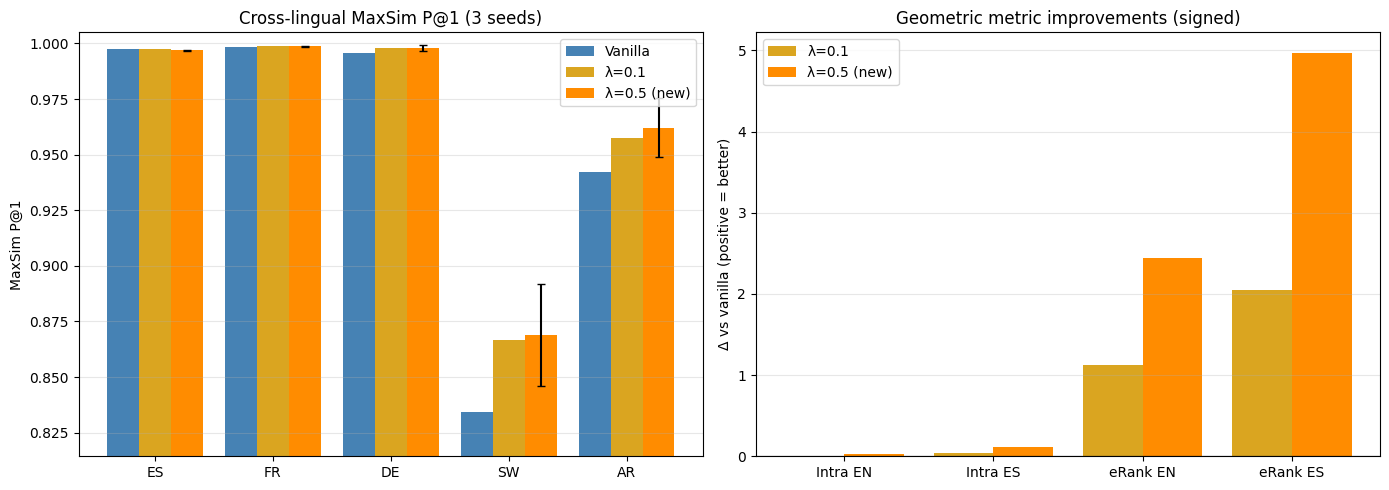

Saved: /content/drive/MyDrive/iso_colbert_lam0p5/lam0p5_summary.png


In [17]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names_p1 = ['ES', 'FR', 'DE', 'SW', 'AR']
keys_p1 = ['p1_es', 'p1_fr', 'p1_de', 'p1_sw', 'p1_ar']

van_mu = [VANILLA_MEANS[k] for k in keys_p1]
i01_mu = [LAM01_MEANS[k] for k in keys_p1]
i05_mu = [agg('iso_lam0p5', k)[0] for k in keys_p1]
i05_sd = [agg('iso_lam0p5', k)[1] for k in keys_p1]

# P@1 chart
ax = axes[0]
x = np.arange(len(names_p1))
w = 0.27
ax.bar(x - w, van_mu, w, label='Vanilla', color='steelblue')
ax.bar(x,     i01_mu, w, label='λ=0.1',   color='goldenrod')
ax.bar(x + w, i05_mu, w, yerr=i05_sd, label='λ=0.5 (new)', color='darkorange', capsize=3)
ax.set_xticks(x); ax.set_xticklabels(names_p1)
ax.set_ylabel('MaxSim P@1')
ax.set_title(f'Cross-lingual MaxSim P@1 ({len(SEEDS)} seeds)')
ax.set_ylim(min(min(van_mu), min(i01_mu), min(i05_mu)) - 0.02, 1.005)
ax.legend(); ax.grid(alpha=0.3, axis='y')

# Geometric metrics: signed delta
ax = axes[1]
geo_keys = ['intra_en', 'intra_es', 'erank_en', 'erank_es']
geo_names = ['Intra EN', 'Intra ES', 'eRank EN', 'eRank ES']

def signed_delta(method_dict_or_agg, k, vanilla_dict):
    if isinstance(method_dict_or_agg, dict):
        mu = method_dict_or_agg[k]
    else:
        mu, _ = method_dict_or_agg
    d = mu - vanilla_dict[k]
    return -d if 'intra' in k else d

i01_d = [signed_delta(LAM01_MEANS, k, VANILLA_MEANS) for k in geo_keys]
i05_d = [signed_delta(agg('iso_lam0p5', k), k, VANILLA_MEANS) for k in geo_keys]

x = np.arange(len(geo_keys))
w = 0.4
ax.bar(x - w/2, i01_d, w, label='λ=0.1', color='goldenrod')
ax.bar(x + w/2, i05_d, w, label='λ=0.5 (new)', color='darkorange')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(geo_names)
ax.set_ylabel('Δ vs vanilla (positive = better)')
ax.set_title('Geometric metric improvements (signed)')
ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'lam0p5_summary.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {os.path.join(SAVE_DIR, "lam0p5_summary.png")}')

## Interpretation

After running, look at the comparison table:

**If λ=0.5 beats λ=0.1 on EN-SW and EN-AR (with consistent signs across seeds):** This is your new headline. EN-SW gain probably moves to +5–6 P@1, EN-AR gain to +2–3. Update the paper's main results table to use λ=0.5 as the headline configuration.

**If λ=0.5 ties with λ=0.1:** Single-seed bump was noise. λ=0.1 stays as headline. You learn that the λ ablation on a single seed isn't reliable — useful framing for the limitations section.

**If λ=0.5 is worse than λ=0.1 in some seeds:** Single-seed λ=0.5 was lucky. Report this honestly — "single-seed λ=0.5 looked best, but multi-seed shows λ=0.1 is more reliable." That's also a valid finding.

In all cases, you have multi-seed validated numbers for both λ=0.1 and λ=0.5, which lets you claim robust λ ablation rather than a single-seed search.